In [1]:
import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy as copy

In [2]:
import sys
sys.path.append('../')
from BPMQ import fmlat, BPMQscan
from BPMQ.utils import calculate_mismatch_factor, calculate_MMD4D, proximal_ordered_init_sampler
from BPMQ.construct_machineIO import construct_machineIO

In [3]:
# Example usage (assuming you have the helper functions defined as before):
filename = "lattice.txt"  # Replace with your lattice file
to_elem = "BDS_BTS:PM_D5567"
lattice_dicts = fmlat.combine_lattice_elements_quads_only(filename, from_element=None, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])

quads_to_scan = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
quads_to_scan = quads_to_scan[:2]
BPM_names = [elem['name'] for elem in lattice_dicts if 'BPM' in elem['name']][1:]

In [4]:
quads_to_scan

['LS3_BTS:PSQ_D4713', 'LS3_BTS:PSQ_D4718']

In [5]:
BPM_names

['LS3_BTS:BPM_D4753',
 'LS3_BTS:BPM_D4769',
 'LS3_BTS:BPM_D4843',
 'LS3_BTS:BPM_D4886',
 'LS3_BTS:BPM_D4968',
 'LS3_BTS:BPM_D5010',
 'LS3_BTS:BPM_D5092',
 'LS3_BTS:BPM_D5134',
 'LS3_BTS:BPM_D5216',
 'LS3_BTS:BPM_D5259',
 'LS3_BTS:BPM_D5340',
 'LS3_BTS:BPM_D5381',
 'LS3_BTS:BPM_D5430',
 'LS3_BTS:BPM_D5445',
 'BDS_BTS:BPM_D5499',
 'BDS_BTS:BPM_D5513',
 'BDS_BTS:BPM_D5565']

In [6]:
benchmark = []
for i in range(1,42):
    benchmark.append(pd.read_hdf(f'benchmark{i}.h5'))
benchmark = pd.concat(benchmark)

In [7]:
len(benchmark)

11808

In [8]:
len(benchmark['mismatch_x_bestcov'][0])

41

# plot

In [9]:
def plot_bar(col, benchmark=benchmark,     condition_cols = ['n_init', 'isEmitPrior', 
                      'sample_model_err', 'virtual_beamQmodelerr', 
                      'bootstrap', 'fit_err', 'isPMscan'], fig_size=(16, 6), plot_sorted_only=False):
    
    df = benchmark.copy()
    try: 
        df[col] = df[col].apply(lambda x: x[-1])
    except:
        pass
        
    grouped = df.groupby(condition_cols)[col]
    summary = df.groupby(condition_cols)[col].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('count', 'count'),
        ('min', 'min'),
        ('max', 'max'),
        ('q10', lambda x: x.quantile(0.1)),
        ('q90', lambda x: x.quantile(0.9)),
        ('q01', lambda x: x.quantile(0.01)),
        ('q99', lambda x: x.quantile(0.99))
    ]).reset_index()
    
    summary['label'] = summary[condition_cols].astype(str).agg('|'.join, axis=1)
    
    
    # =====plot, sort by mean======
    summary = summary.sort_values(by=condition_cols)
    x_labels = summary['label']
    means = summary['mean']
    error_lower = np.clip(summary['mean'] - summary['q10'],a_min=0,a_max=1e3)
    error_upper = np.clip(summary['q90'] - summary['mean'],a_min=0,a_max=1e3)
    if not plot_sorted_only:
        plt.figure(figsize=fig_size)
        plt.bar(x_labels, means, yerr=[error_lower, error_upper], capsize=5, alpha=0.8, color='skyblue')
        plt.xticks(rotation=90, fontsize=8)
        plt.ylabel(col.removesuffix('_best'))
        plt.title('10th–90th Percentile Error Bars')
        plt.tight_layout()
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.show()
    
    
    # =====plot, sort by conditions ======
    summary = summary.sort_values('mean')
    x_labels = summary['label']
    means = summary['mean']
    error_lower = np.clip(summary['mean'] - summary['q10'],a_min=0,a_max=1e3)
    error_upper = np.clip(summary['q90'] - summary['mean'],a_min=0,a_max=1e3)
    plt.figure(figsize=fig_size,dpi=128)
    plt.bar(x_labels, means, yerr=[error_lower, error_upper], capsize=5, alpha=0.8, color='skyblue')
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel(col.removesuffix('_best'))
    plt.title('10th–90th Percentile Error Bars')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def get_data_mean_err(group, col, q=0.1):
    """
    Given a group (DataFrame) with column 'MMD_best' as np.arrays,
    return mean and quantile-based error bars per epoch.
    """
    col_array = np.stack(group[col].values)  # shape: (n_samples, 10)
    mean = col_array.mean(axis=0)
    lower = np.clip(mean - np.quantile(col_array, q, axis=0),a_min=0,a_max=np.inf)
    upper = np.clip(np.quantile(col_array, 1 - q, axis=0) - mean,a_min=0,a_max=np.inf)
    return mean, lower, upper


def plot_conditions(df, selected_conditions, labels):
    """
    Plots specified metrics for selected condition combinations.

    selected_conditions: List of tuples with condition values.
    labels: List of strings labeling each condition group.
    """
    group_cols = ['n_init', 'isEmitPrior', 'sample_model_err', 
                  'virtual_beamQmodelerr', 'bootstrap', 'fit_err', 'isPMscan']

    metric_cols = ['MMD_best', 'MMD_mean', 'mismatch_x_bestcov', 'mismatch_y_bestcov']

    for metric_col in metric_cols:
#         print(f"\n=== Plotting metric: {metric_col} ===")
        benchmarks = []

        for idx, condition in enumerate(selected_conditions):
            condition_dict = dict(zip(group_cols, condition))
            group = df.copy()
#             print(f"\n-- Condition {idx}: {labels[idx]} --")
#             print(f"Condition dict: {condition_dict}")
            for ccol, val in condition_dict.items():
                group = group[group[ccol] == val]
#             print(f"Group size after filtering: {len(group)}")

            if len(group) == 0:
                print(f"⚠️ Warning: No data for condition {labels[idx]}")
            else:
                sample_shapes = []
                for v in group[metric_col].values[:3]:
                    try:
                        shape = np.array(v).shape
                        sample_shapes.append(shape)
                    except Exception as e:
                        sample_shapes.append(f"Error: {e}")
#                 print(f"Sample shapes in '{metric_col}':", sample_shapes)

            benchmarks.append((condition, group))

        # Prepare plot
        fig, ax = plt.subplots(figsize=(14, 6),dpi=128)
        shift = 0.03  # Shift for avoiding overlap
        x_base = np.arange(10) + 1  # Epochs: 1 to 10

        for i, (cond, group) in enumerate(benchmarks):
            label = labels[i]

            if len(group) == 0:
                continue

            try:
                mean, lower, upper = get_data_mean_err(group, metric_col, q=0.1)
                x = x_base + (i - len(benchmarks)/2) * shift
#                 print(f"\n[Q=0.0] {label}: mean shape = {mean.shape}, x shape = {x.shape}")
                ax.errorbar(x, mean, yerr=[lower, upper], fmt='-o', alpha=0.2, color=f'C{i}')

                mean, lower, upper = get_data_mean_err(group, metric_col, q=0.2)
#                 print(f"[Q=0.1] {label}: mean shape = {mean.shape}, x shape = {x.shape}")
                ax.errorbar(x, mean, yerr=[lower, upper], fmt='-o', label=label, color=f'C{i}')
            except Exception as e:
                print(f"❌ Error for label {label}: {e}")

        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric_col)
        ax.set_title(metric_col + ' over Epochs')
        ax.legend()
        ax.set_xticks(x_base)
        plt.tight_layout()
        plt.show()


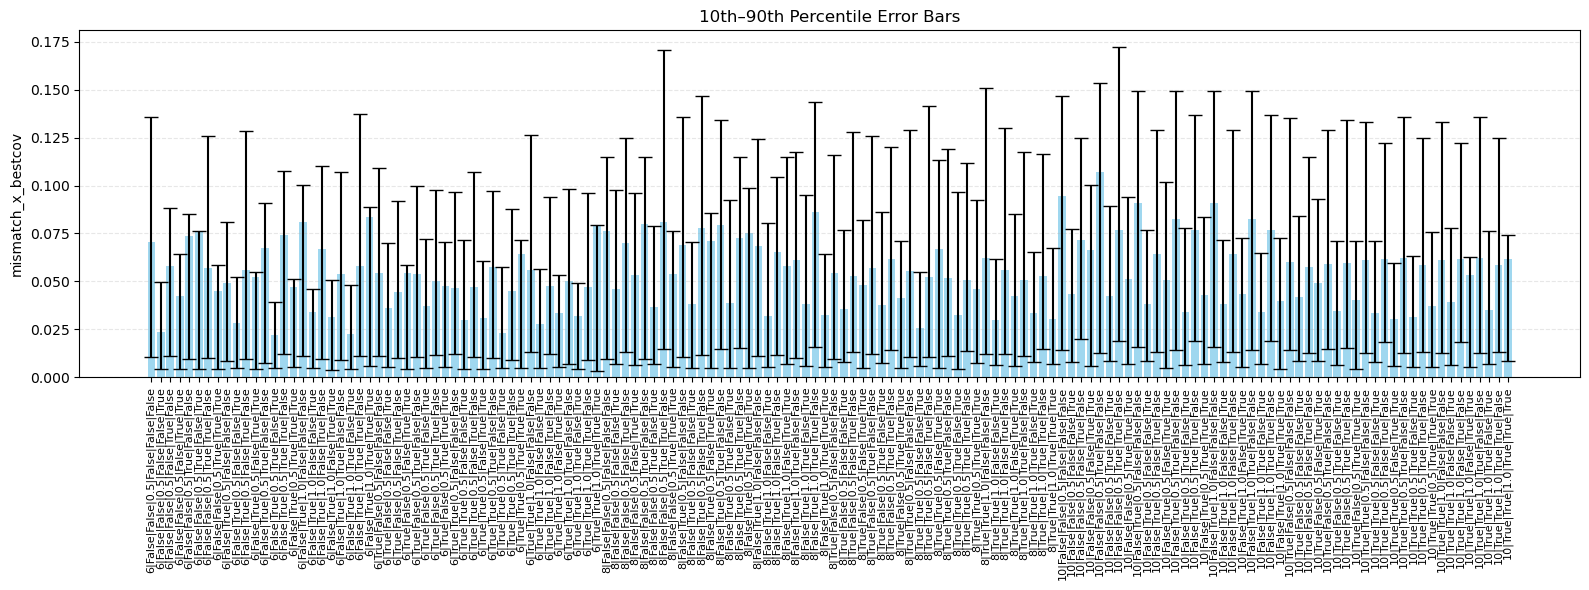

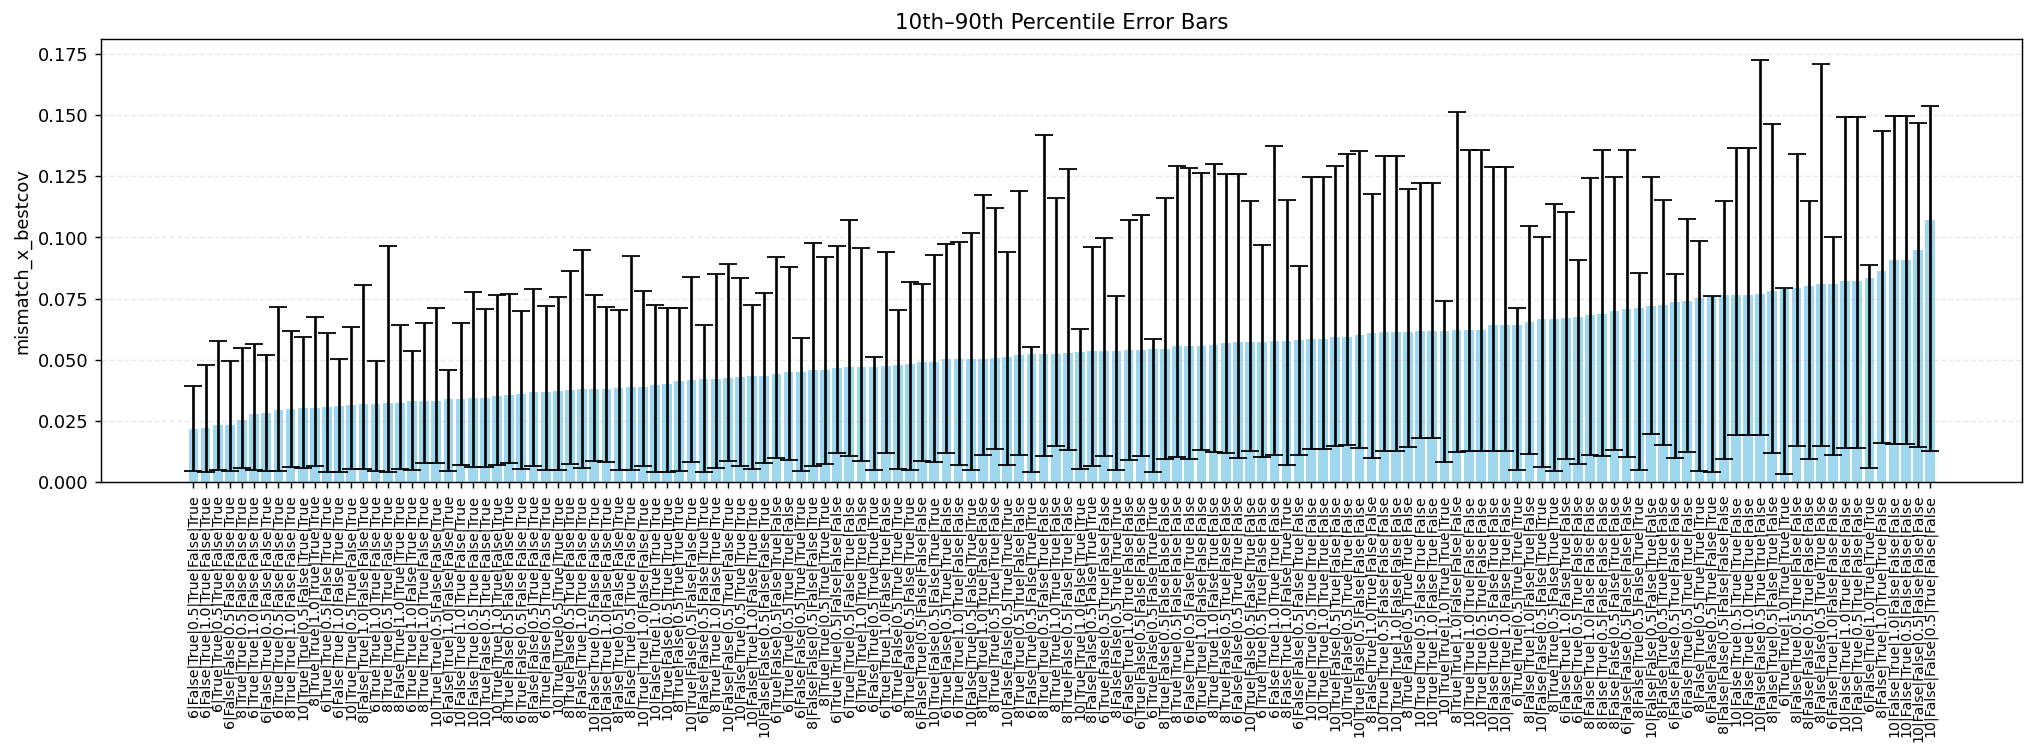

In [11]:
plot_bar('mismatch_x_bestcov')

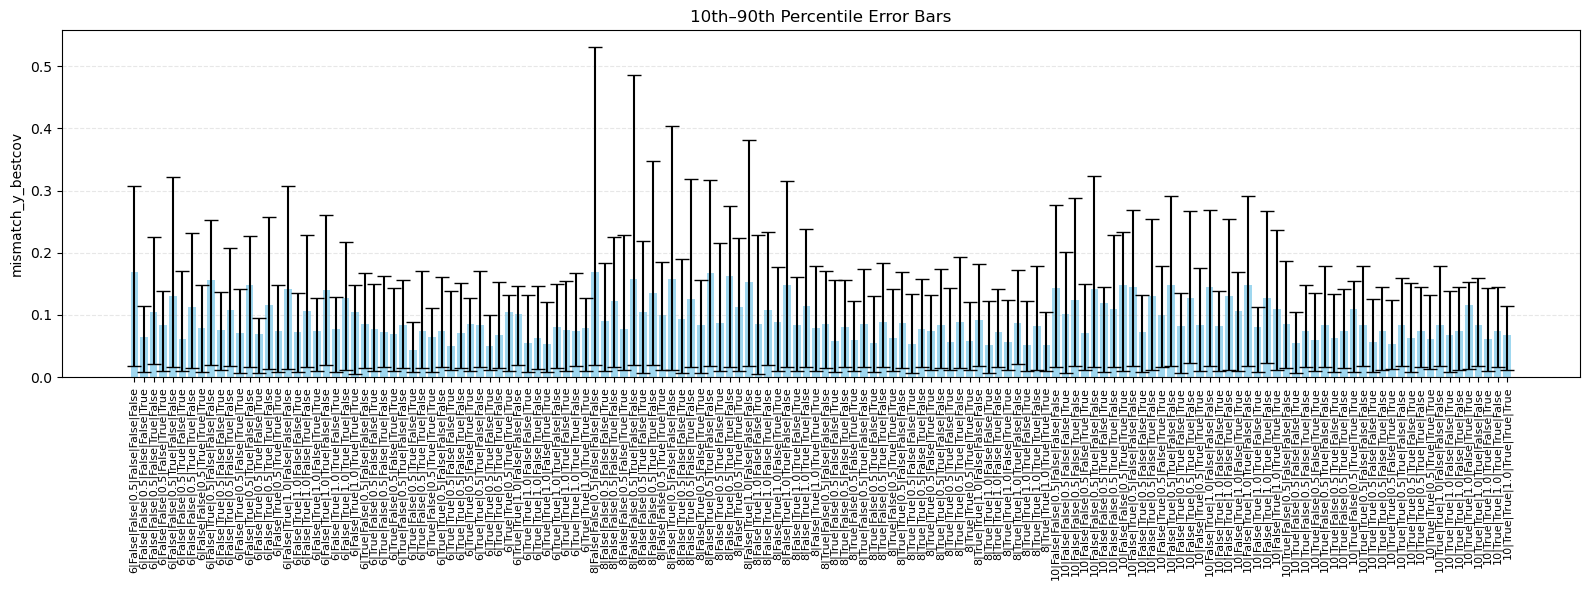

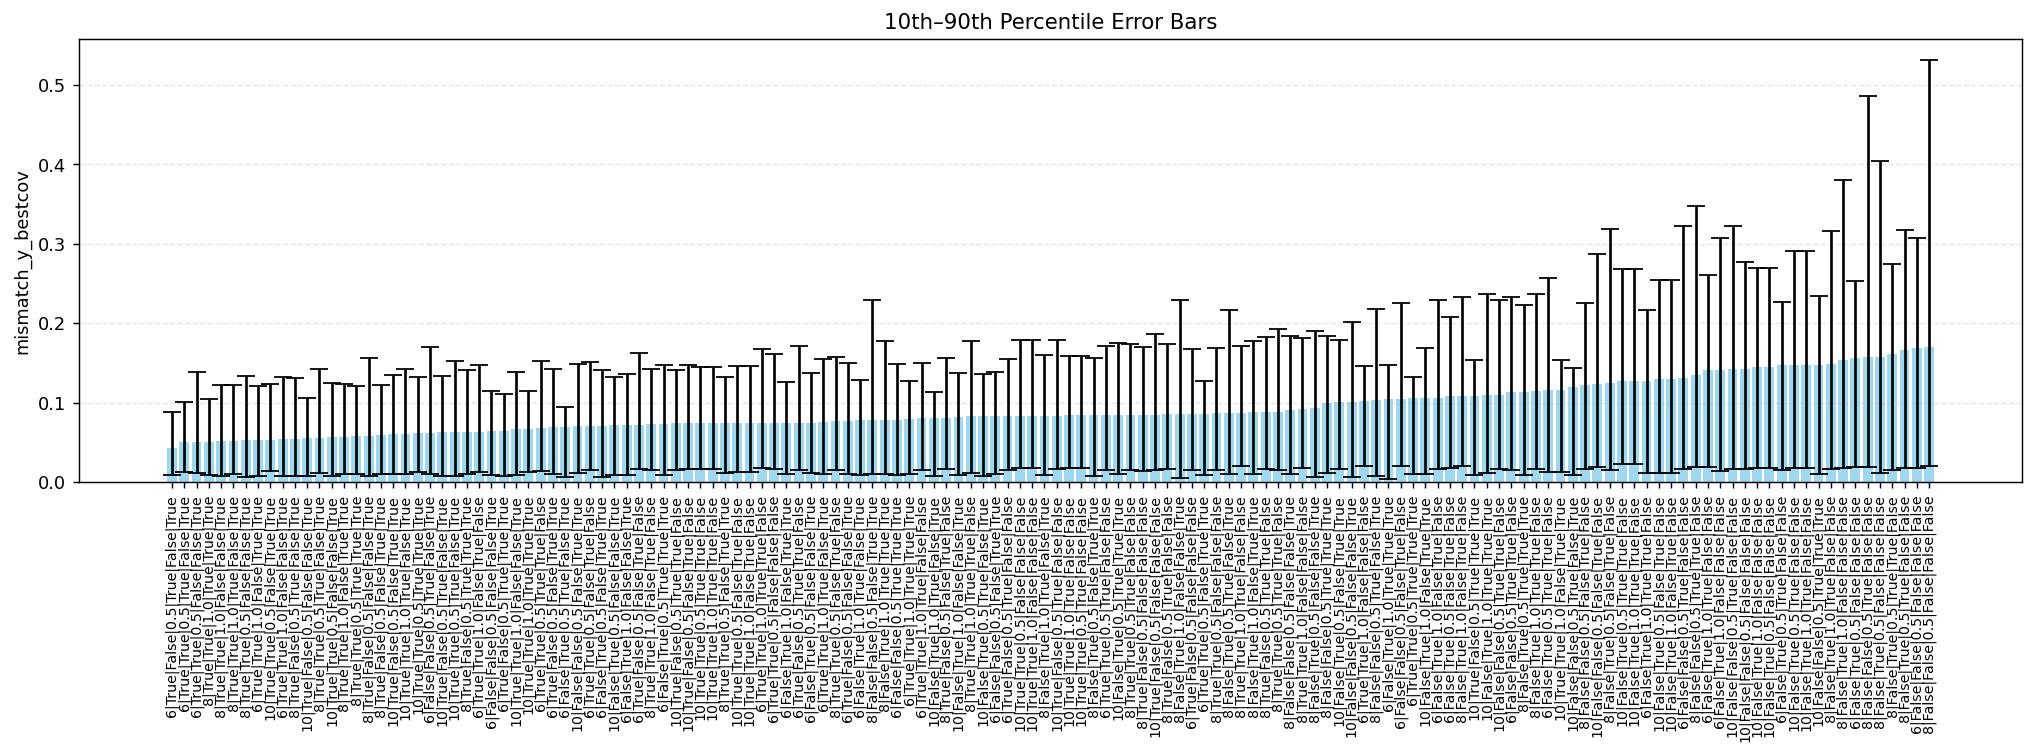

In [12]:
plot_bar('mismatch_y_bestcov')

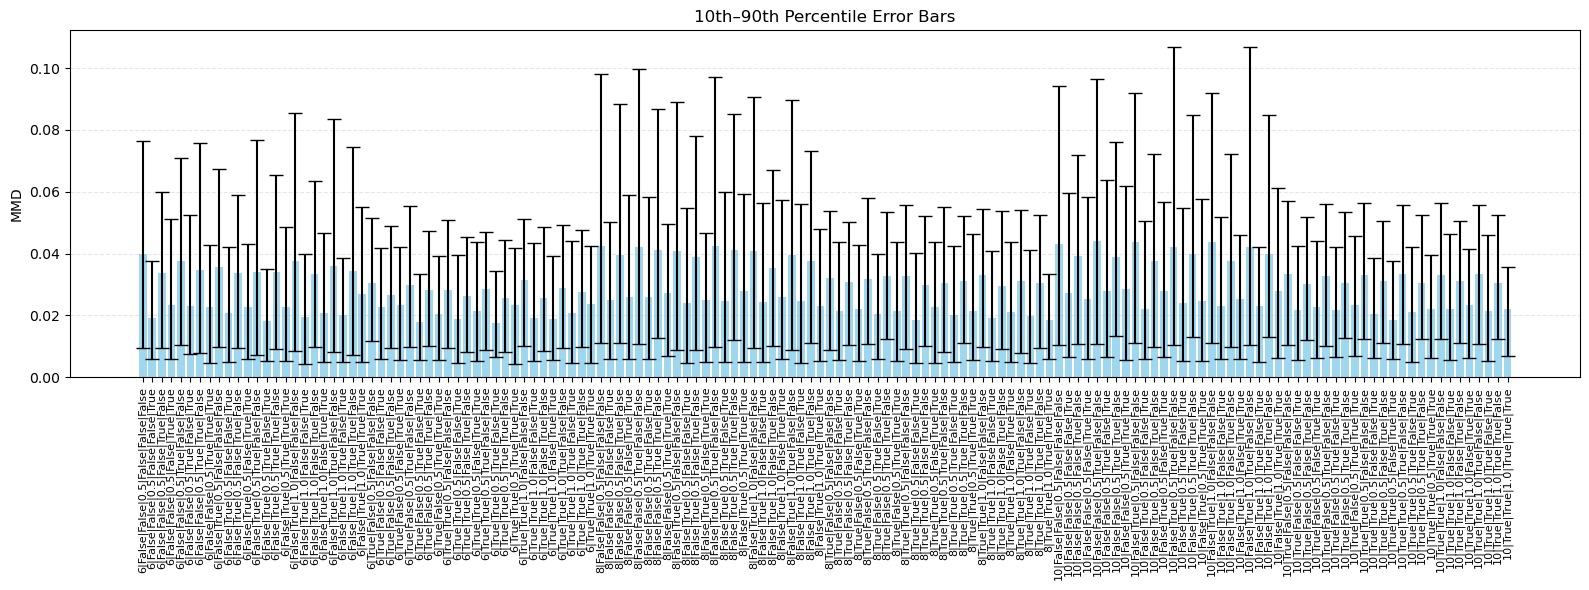

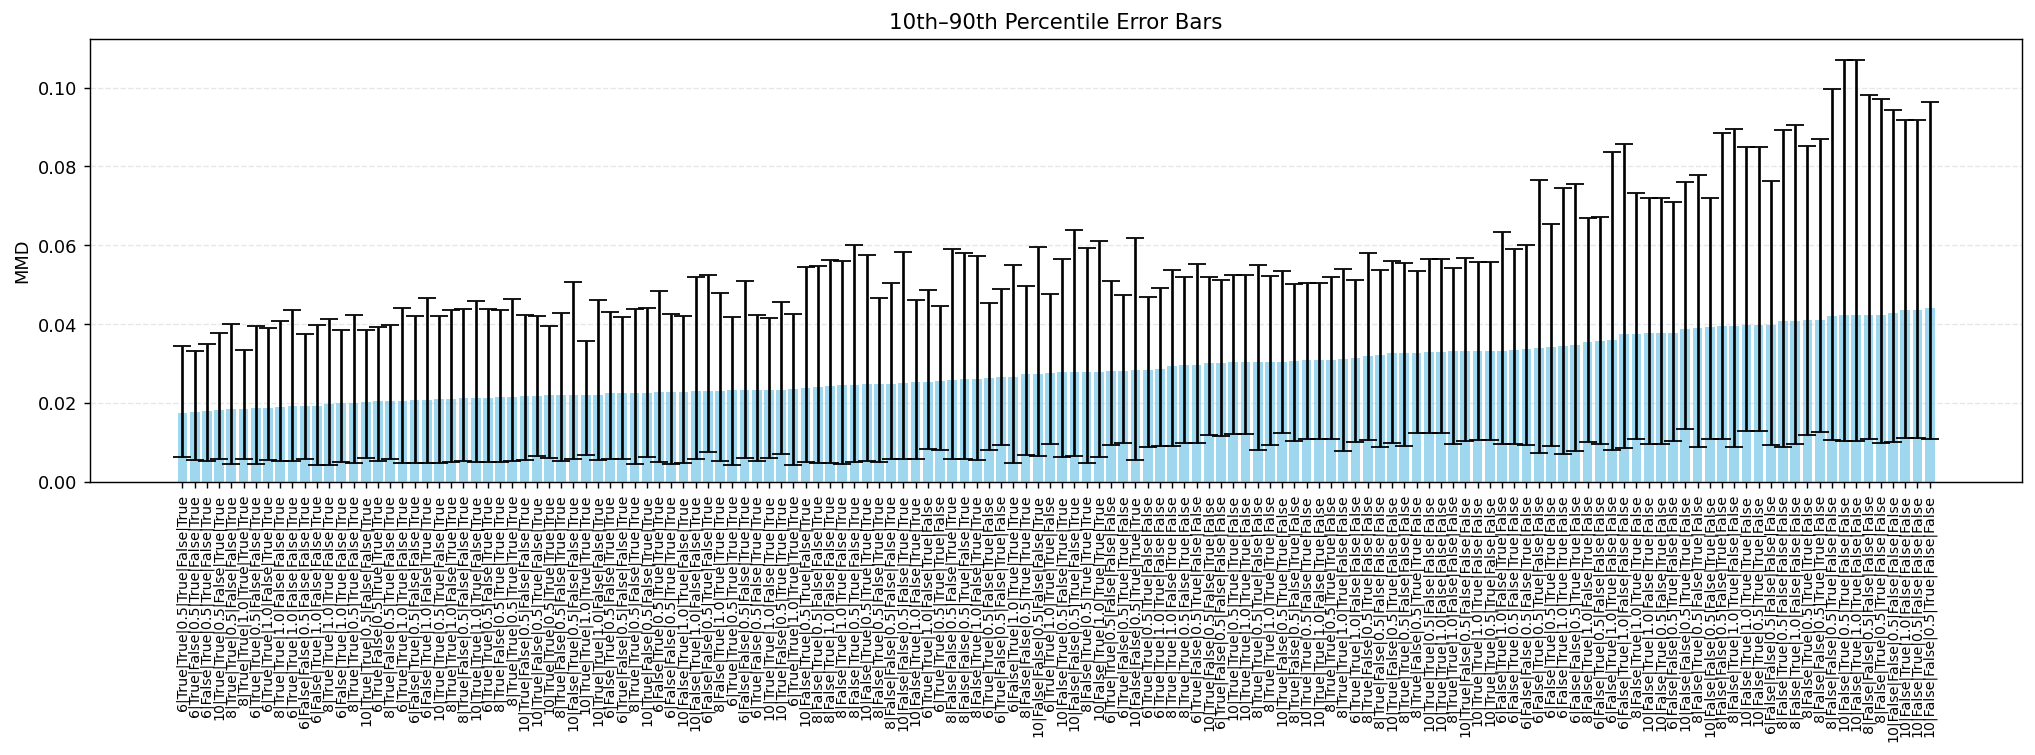

In [13]:
plot_bar('MMD_best')

In [14]:
# ['n_init', 'isEmitPrior', 'sample_model_err', 
#  'virtual_beamQmodelerr', 'bootstrap', 'fit_err', 'isPMscan']

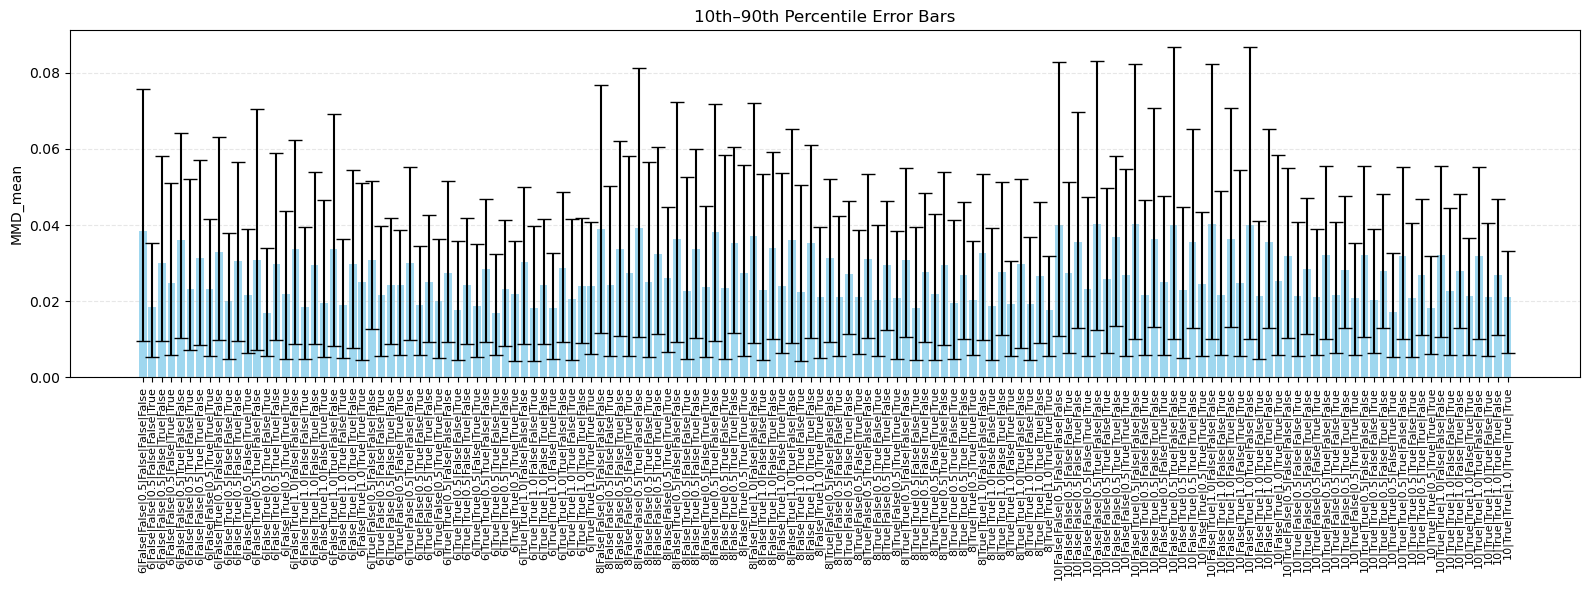

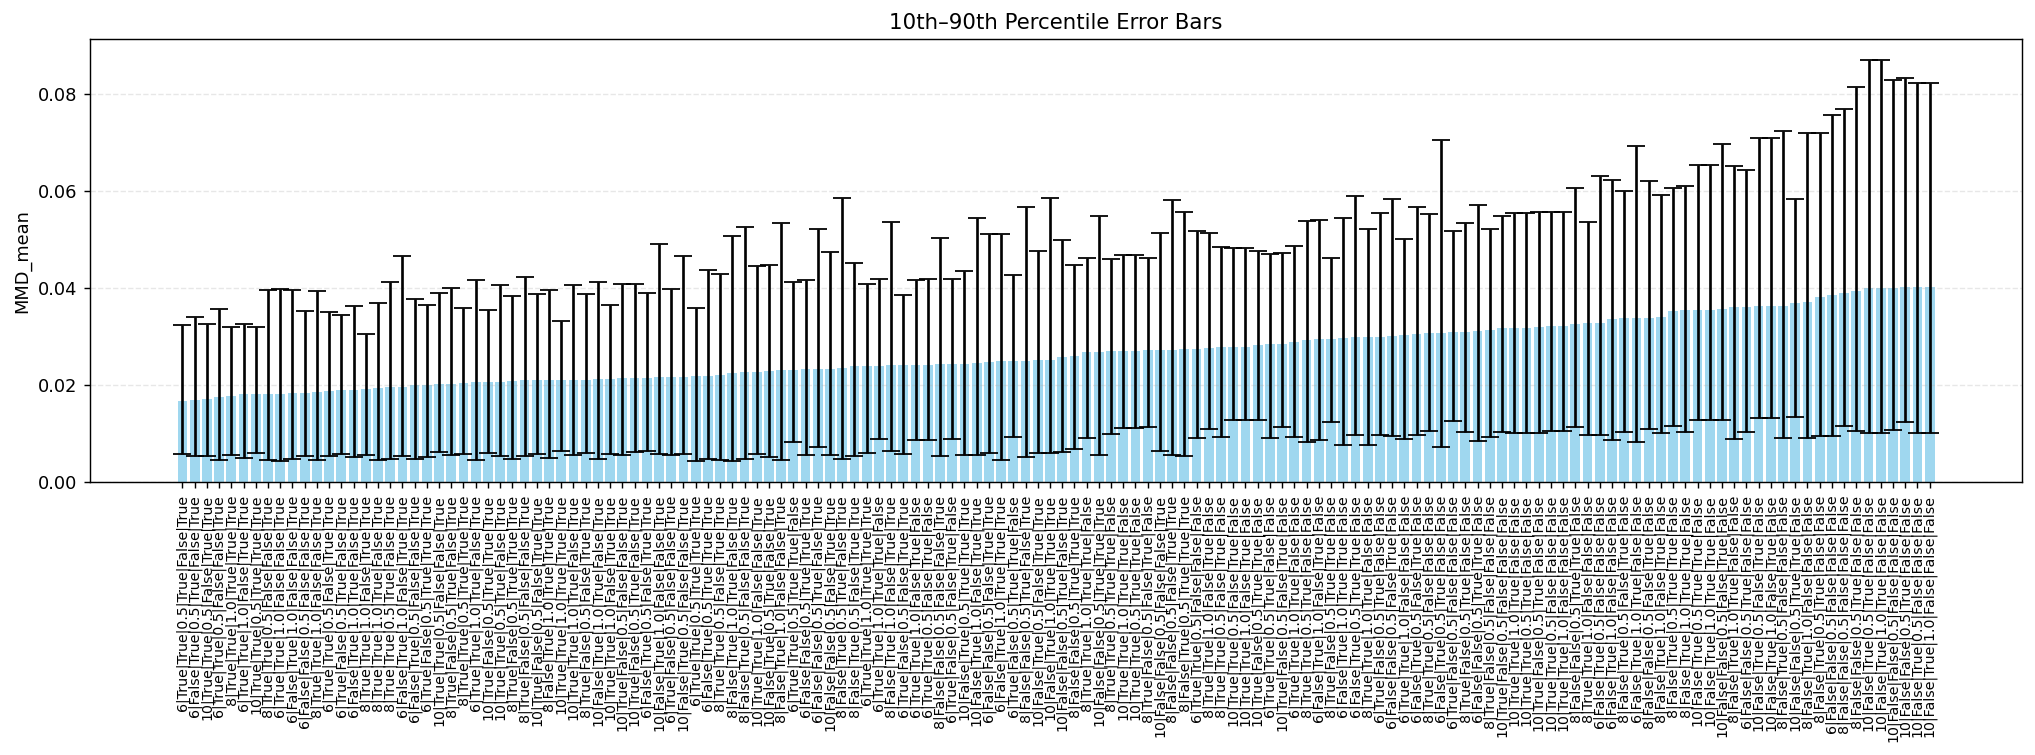

In [15]:
plot_bar('MMD_mean')

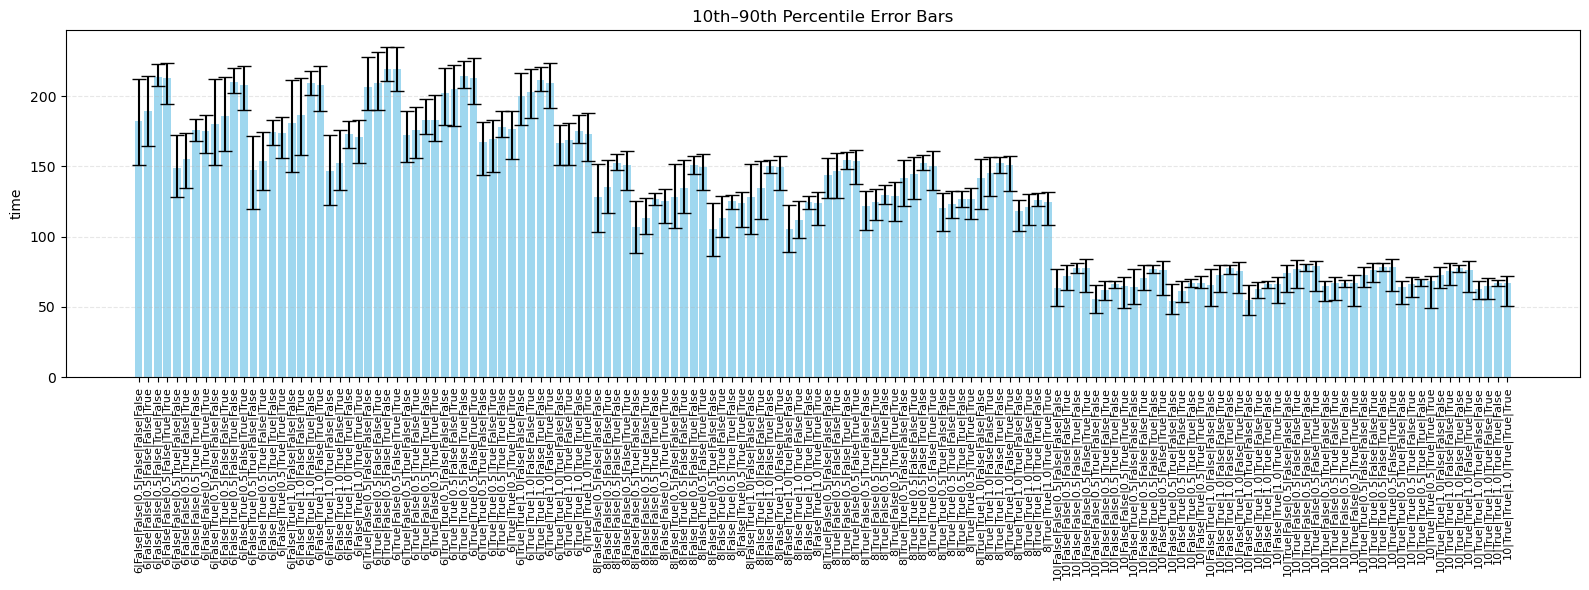

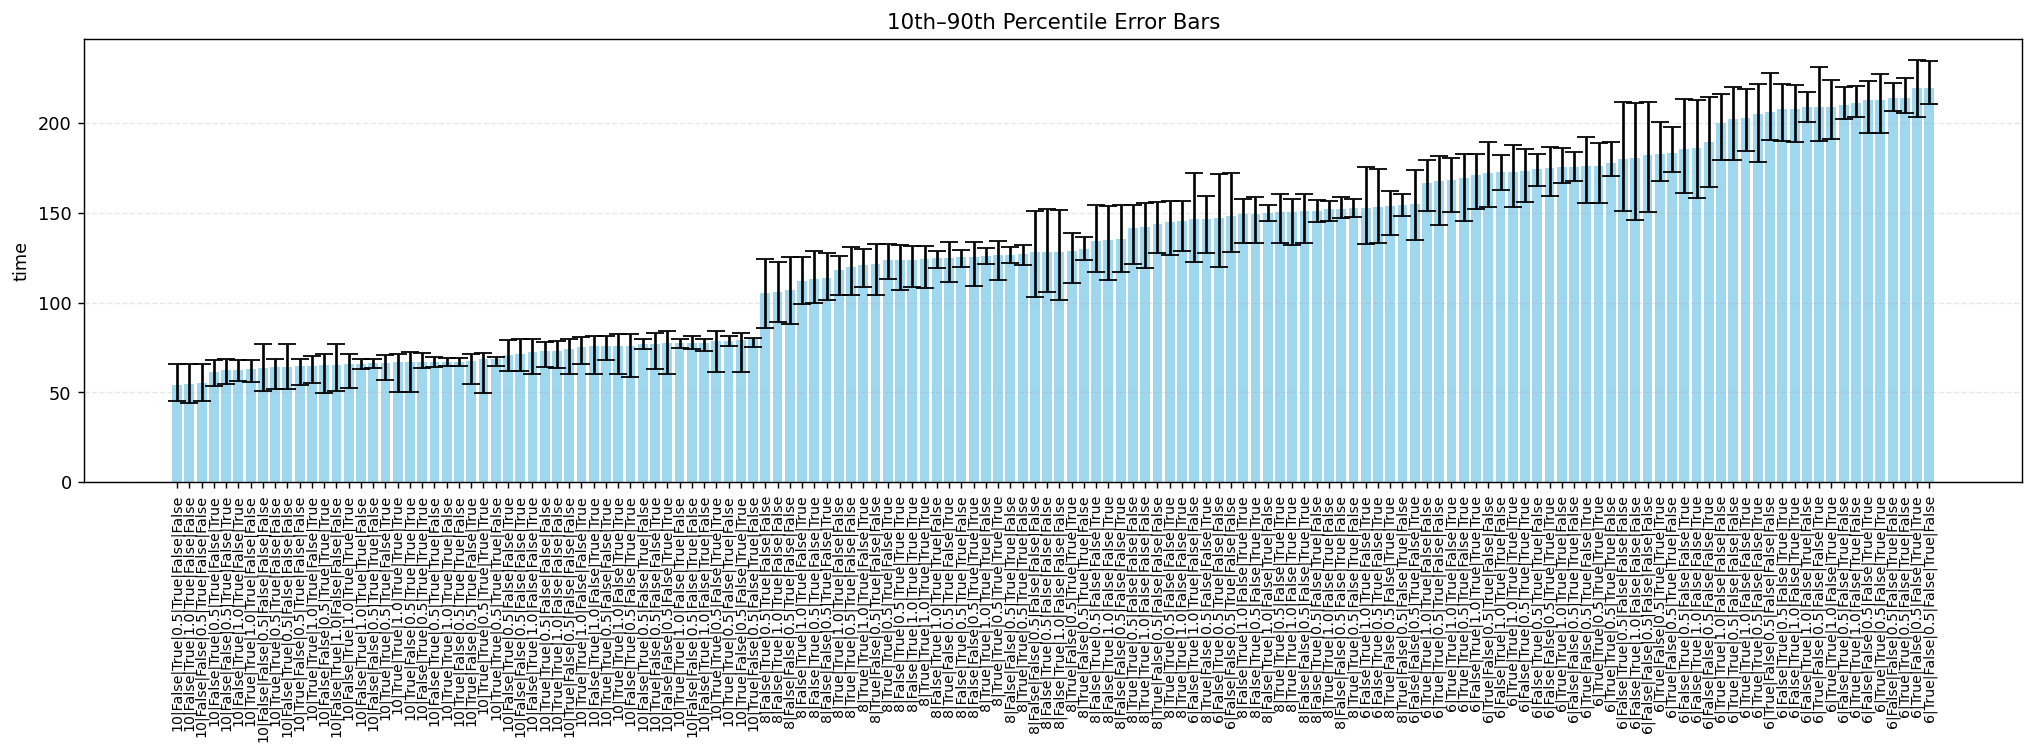

In [16]:
plot_bar('time')

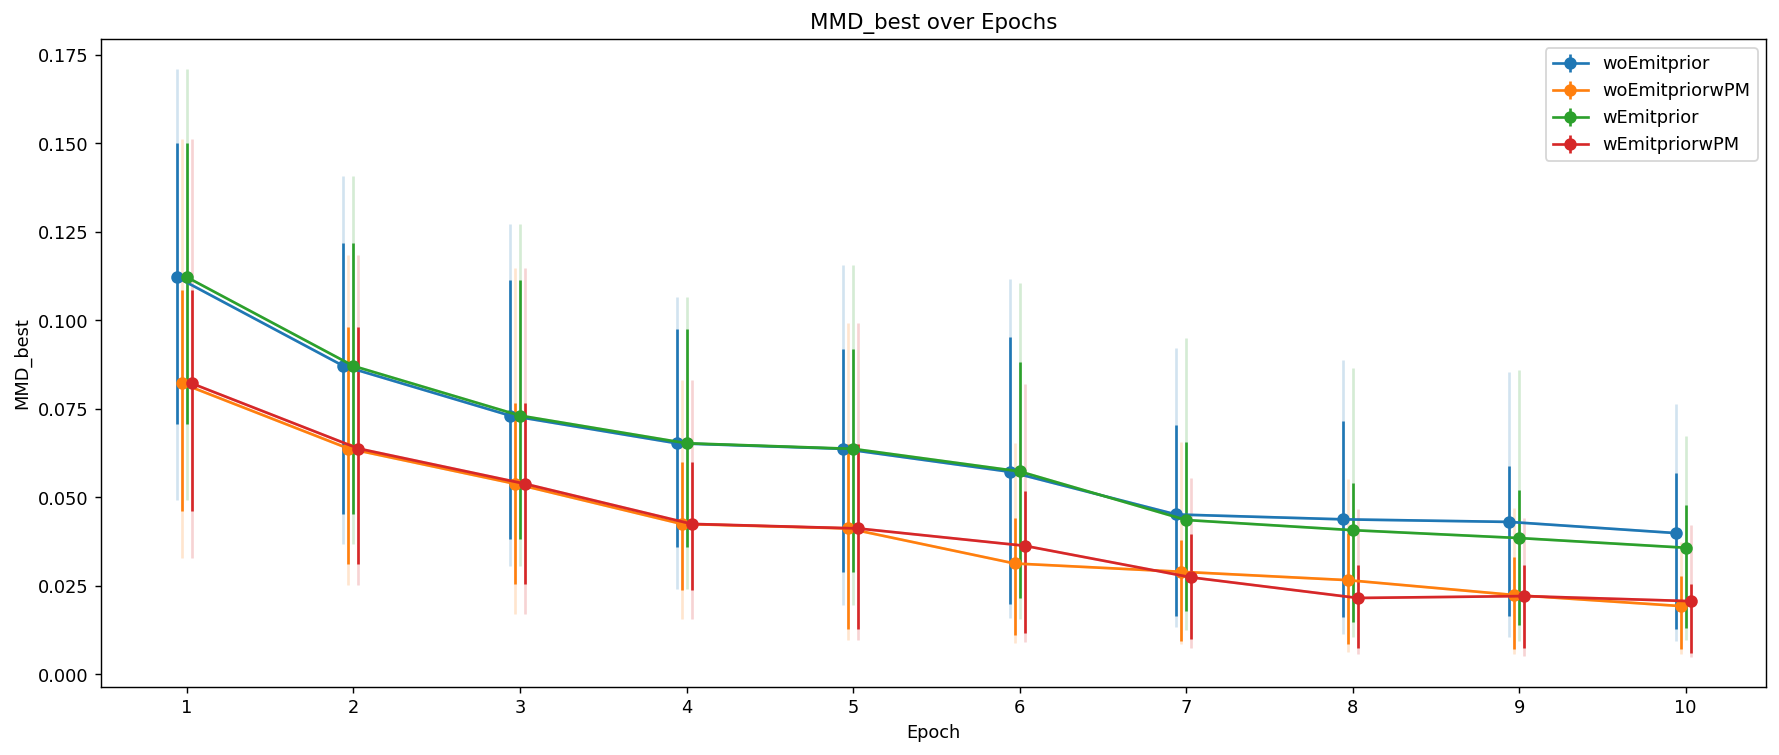

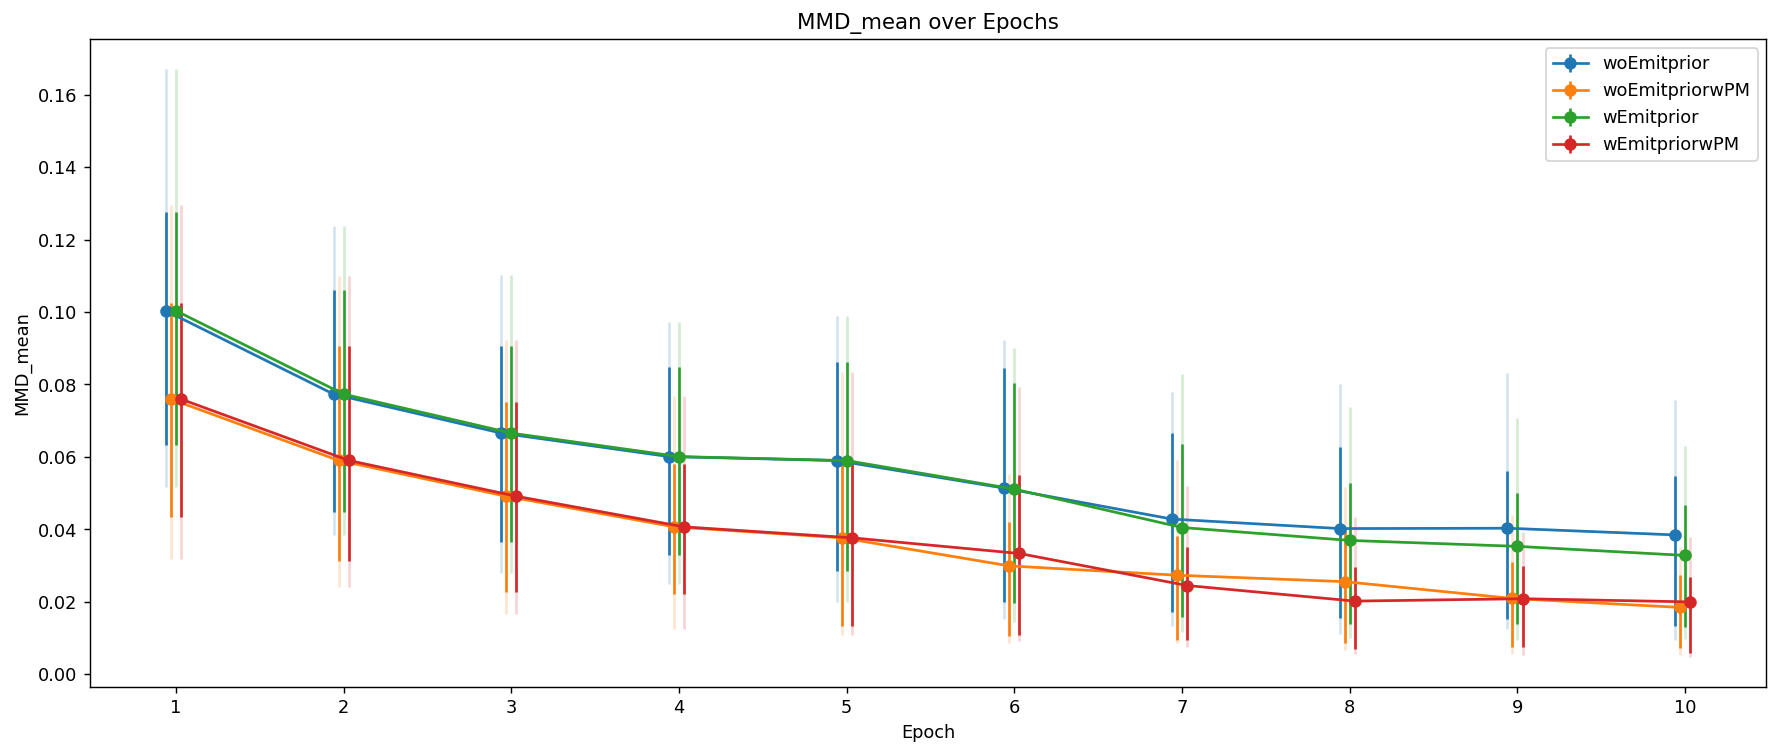

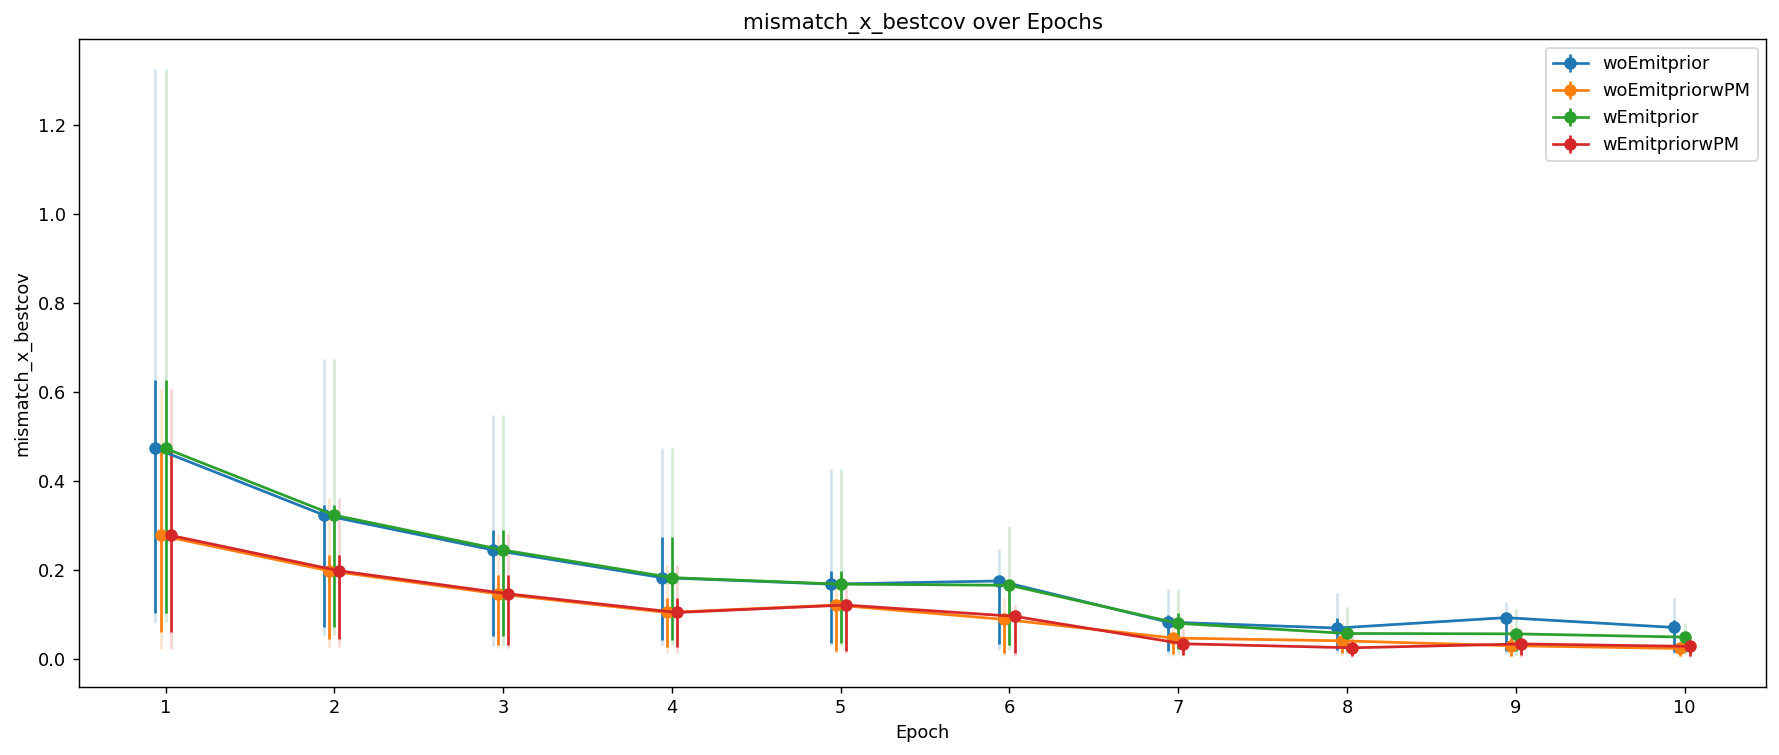

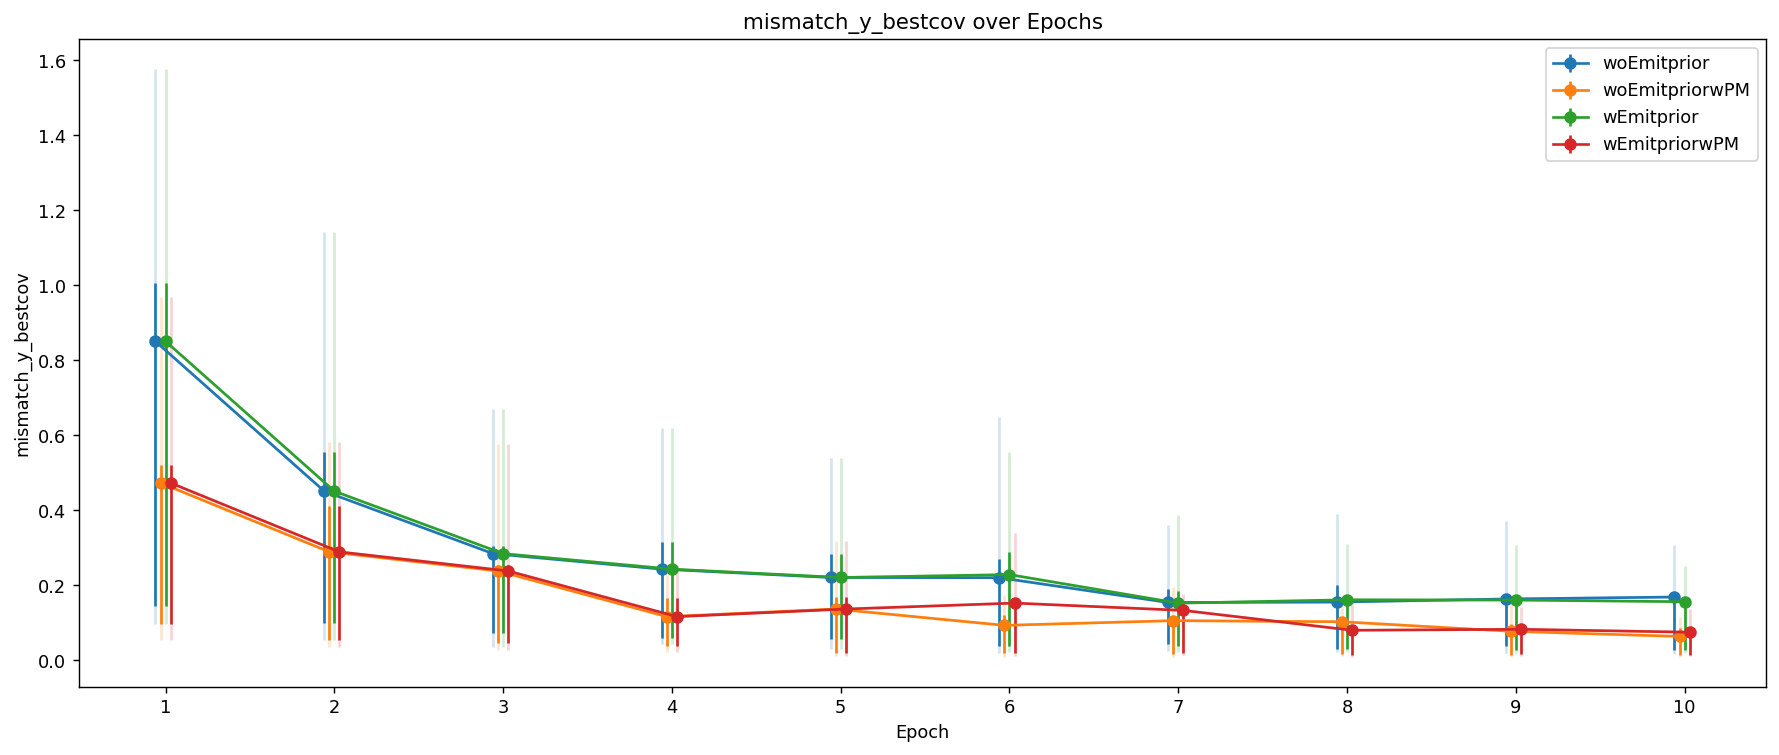

In [17]:
# Example: list of specific conditions to plot
# ['n_init', 'isEmitPrior', 'sample_model_err', 
#  'virtual_beamQmodelerr', 'bootstrap', 'fit_err', 'isPMscan']
selected_conditions = [
    (6, False, False, 0.5, False, False, False),
    (6, False, False, 0.5, False, False, True ),
    (6, False, True , 0.5, False, False, False),
    (6, False, True , 0.5, False, False, True ),

]
# Plot the conditions
plot_conditions(benchmark, selected_conditions,labels=['woEmitprior','woEmitpriorwPM',
                                                       'wEmitprior','wEmitpriorwPM',
                                                       ])

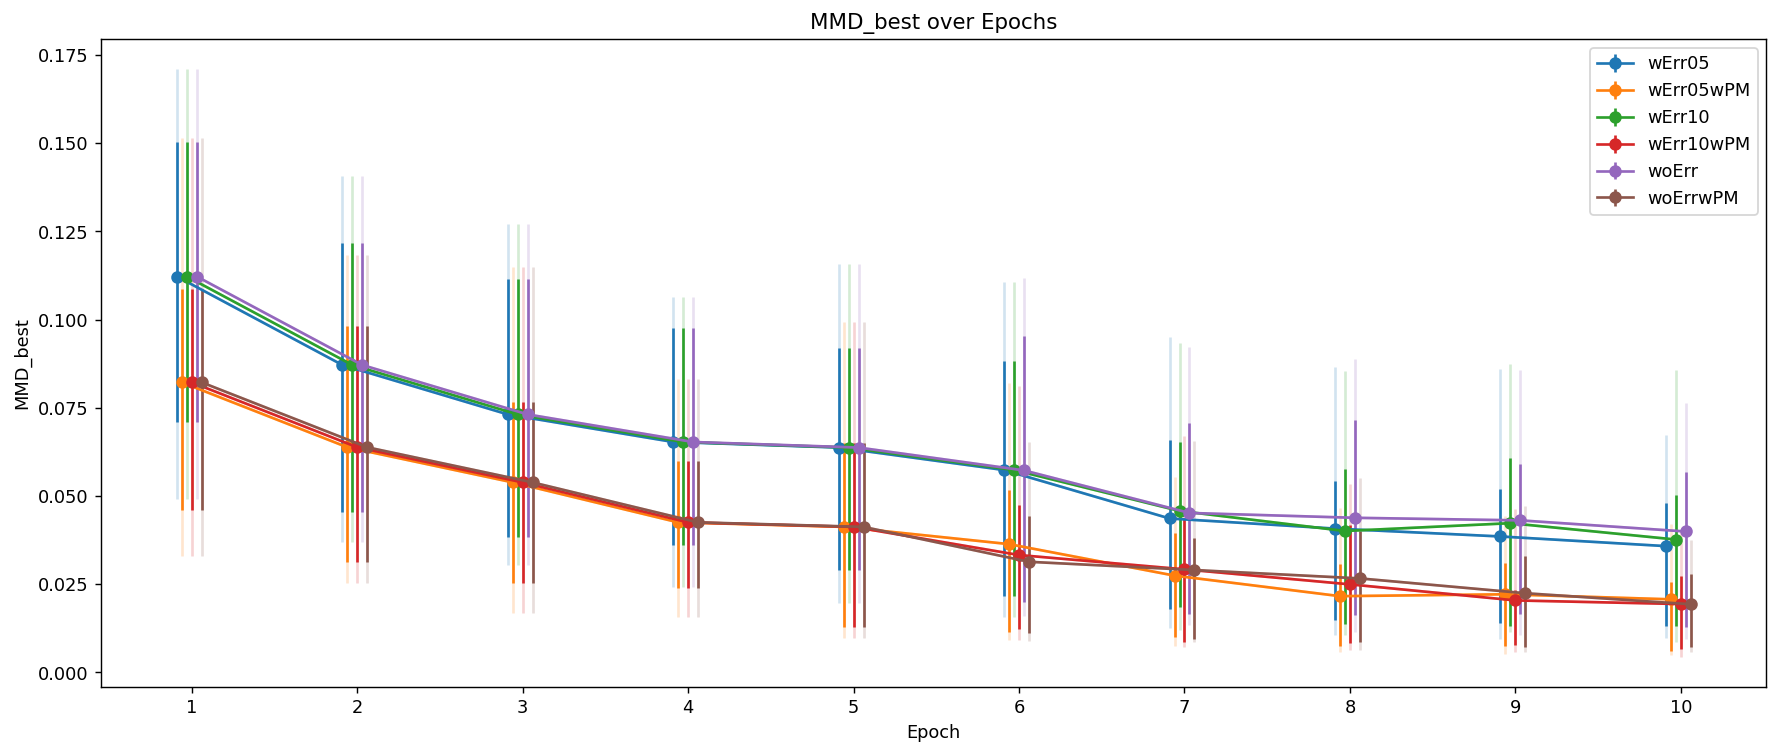

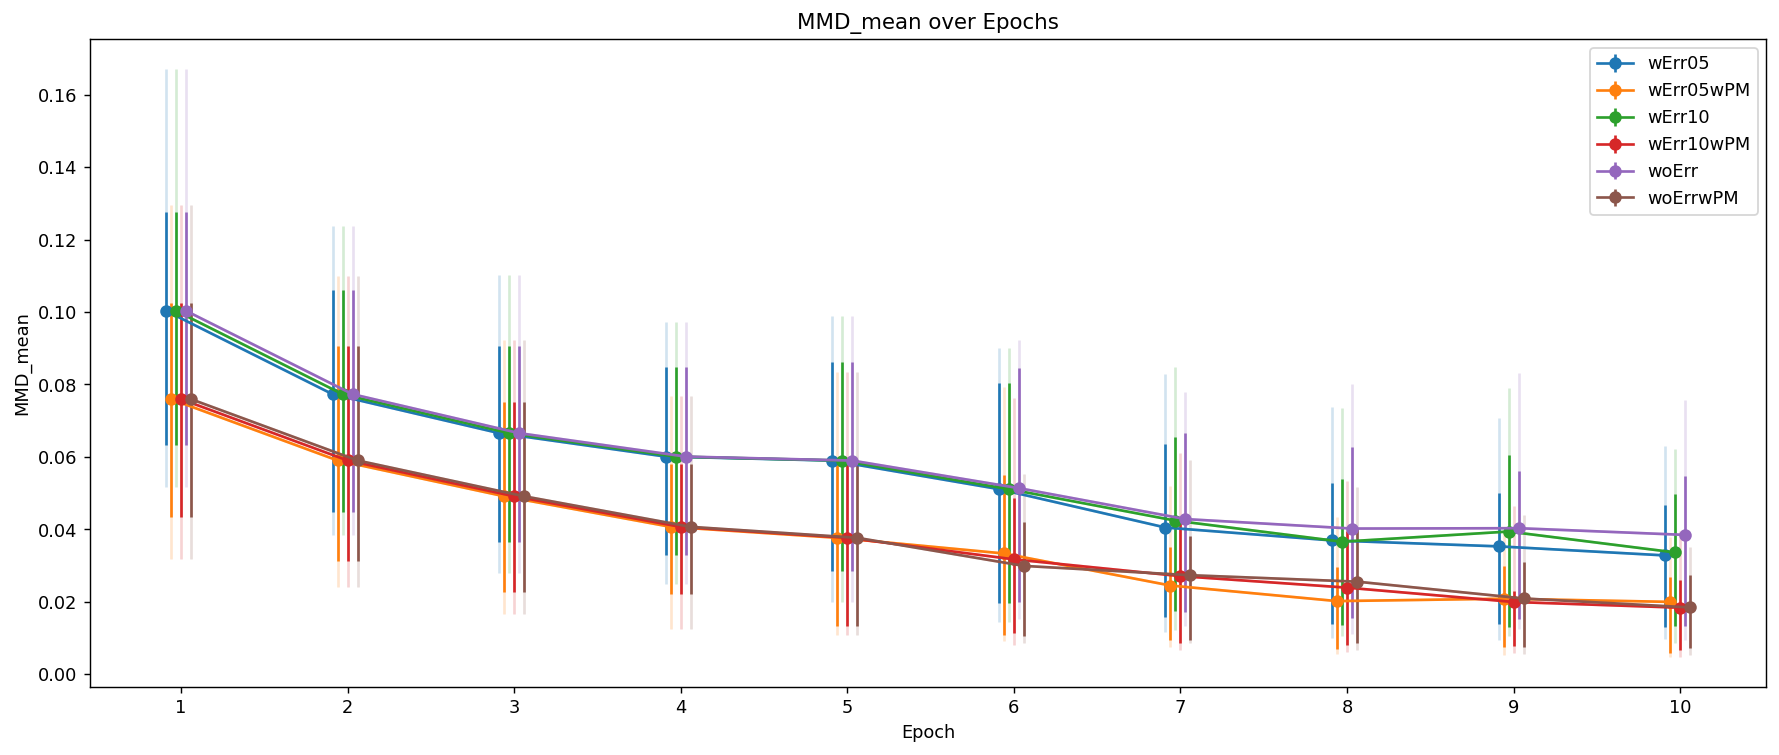

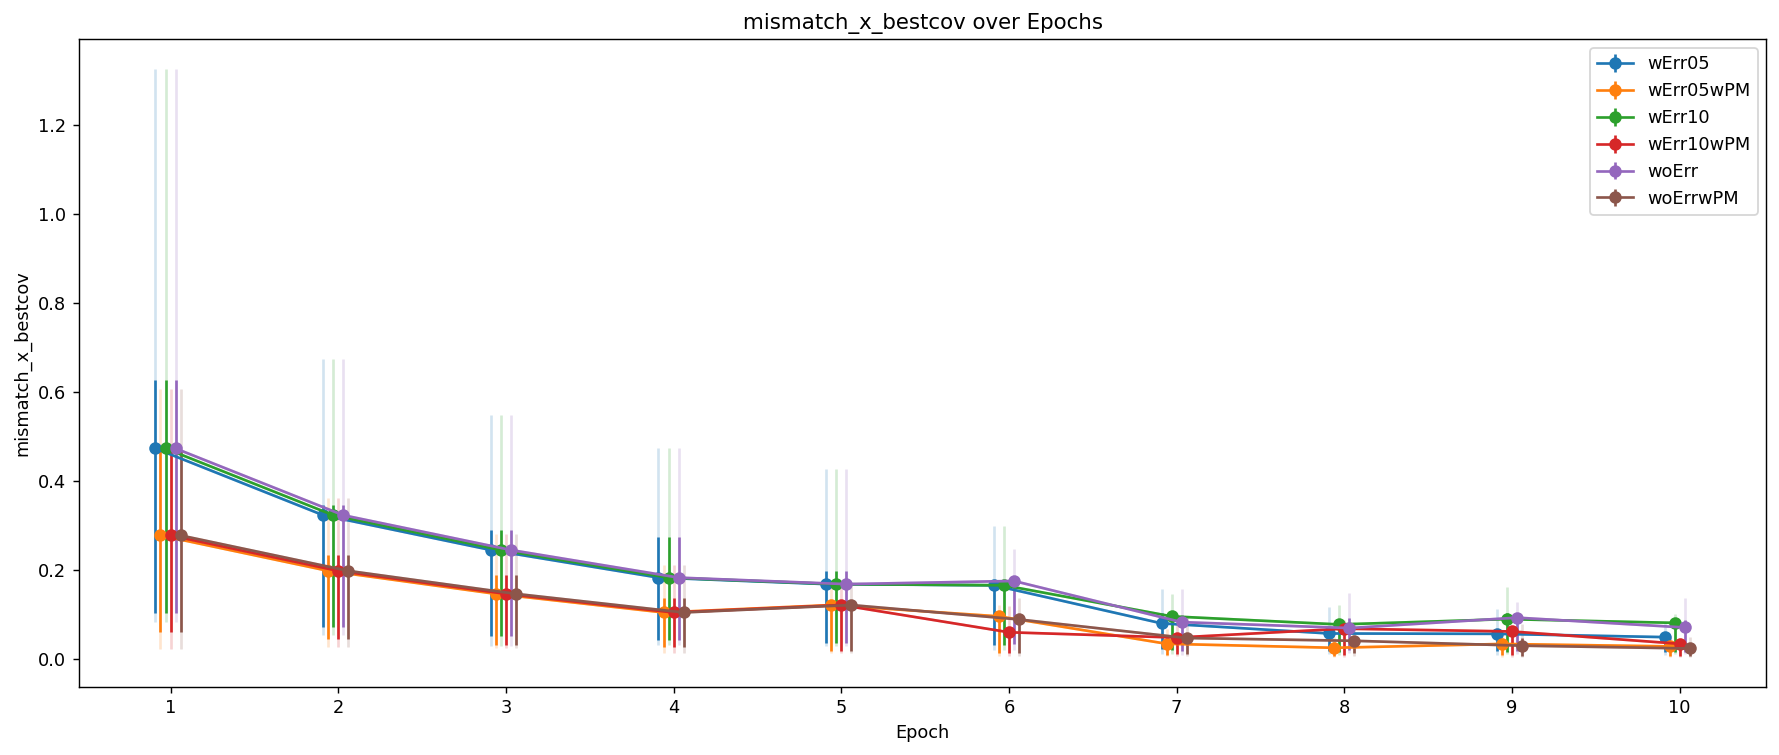

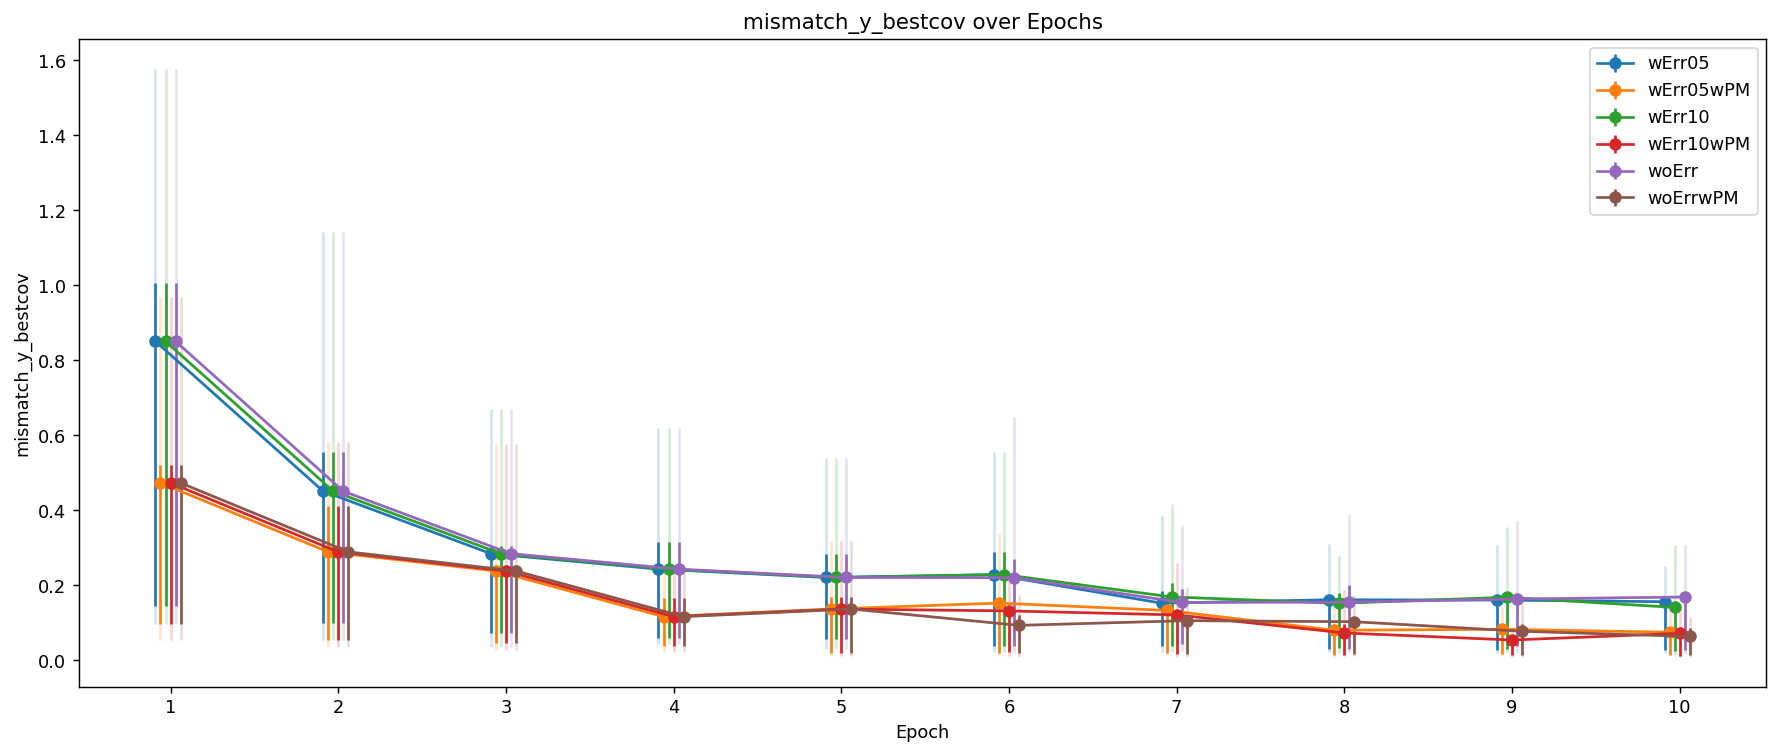

In [18]:
# Example: list of specific conditions to plot
# ['n_init', 'isEmitPrior', 'sample_model_err', 
#  'virtual_beamQmodelerr', 'bootstrap', 'fit_err', 'isPMscan']
selected_conditions = [
    (6, False, True,  0.5, False, False, False),
    (6, False, True,  0.5, False, False, True),
    (6, False, True,  1.0, False, False, False),
    (6, False, True,  1.0, False, False, True),
    (6, False, False, 0.5, False, False, False),
    (6, False, False, 0.5, False, False, True)
]
# Plot the conditions
plot_conditions(benchmark, selected_conditions,labels=['wErr05','wErr05wPM',
                                                       'wErr10','wErr10wPM',
                                                       'woErr','woErrwPM'])

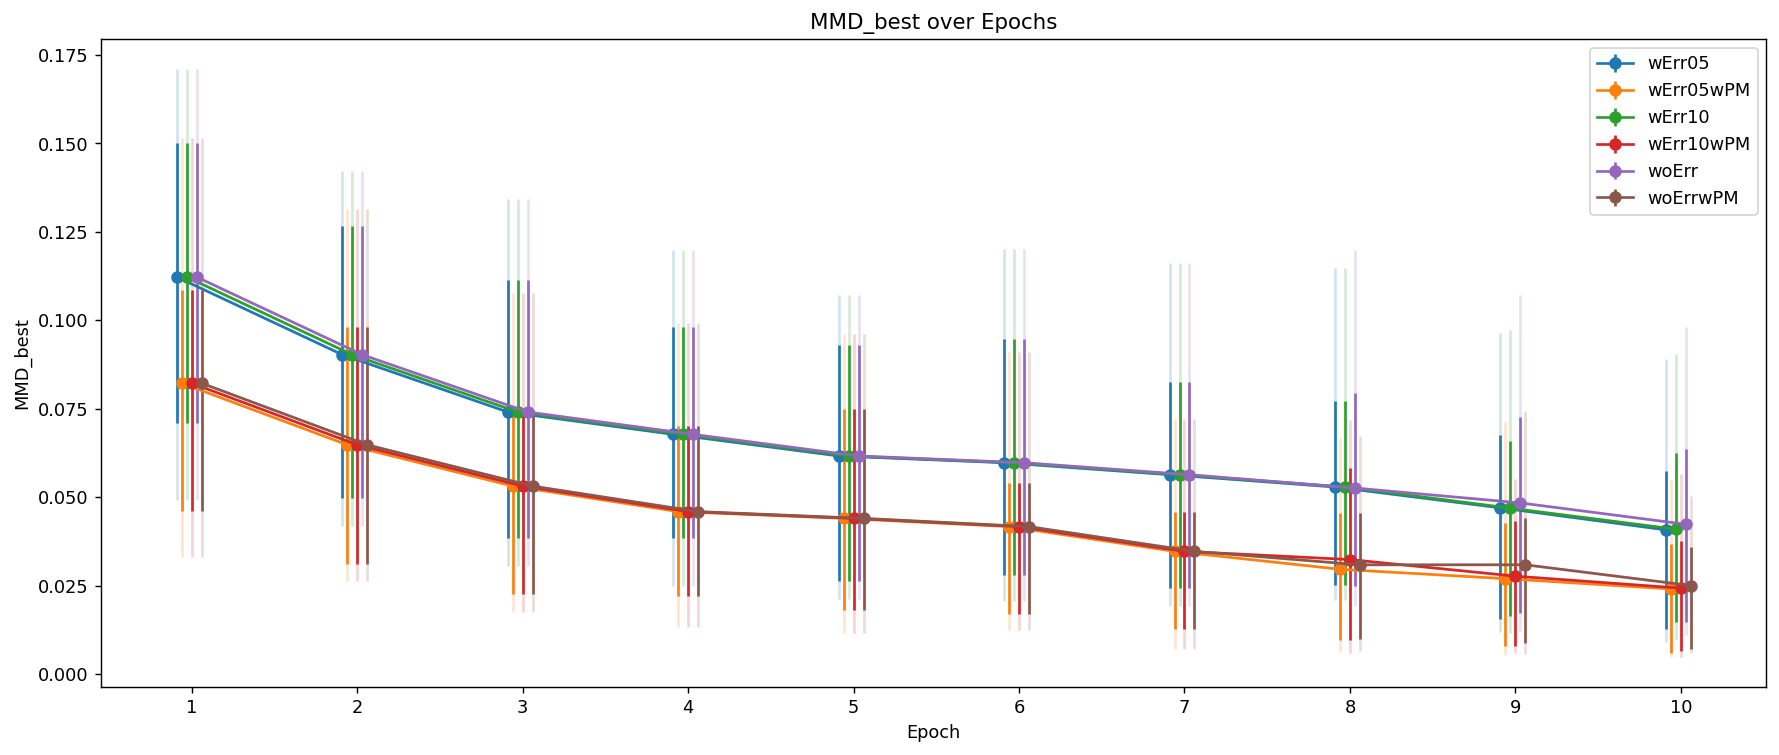

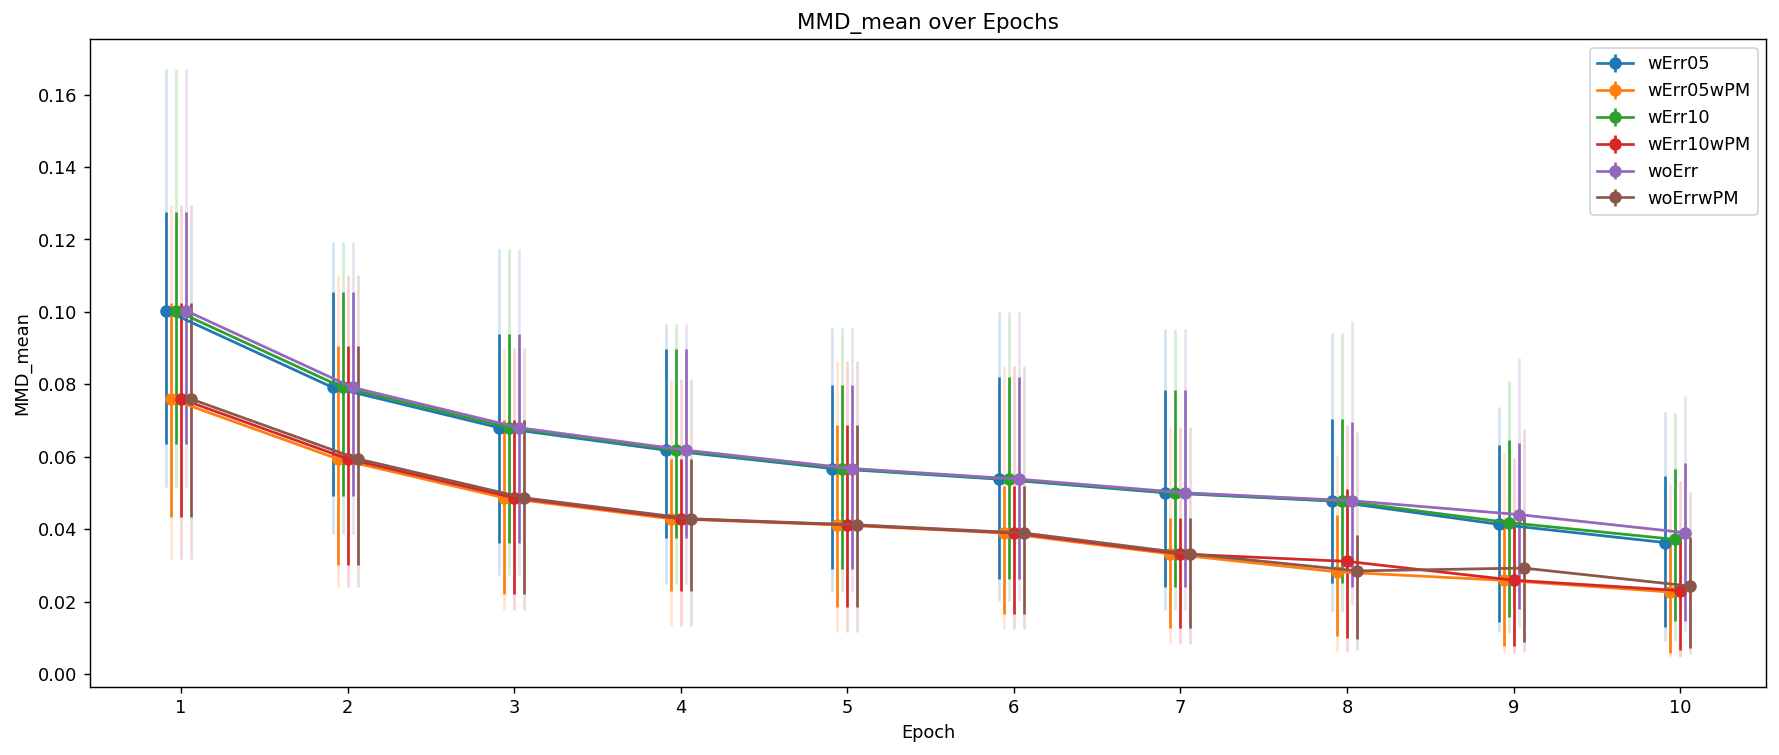

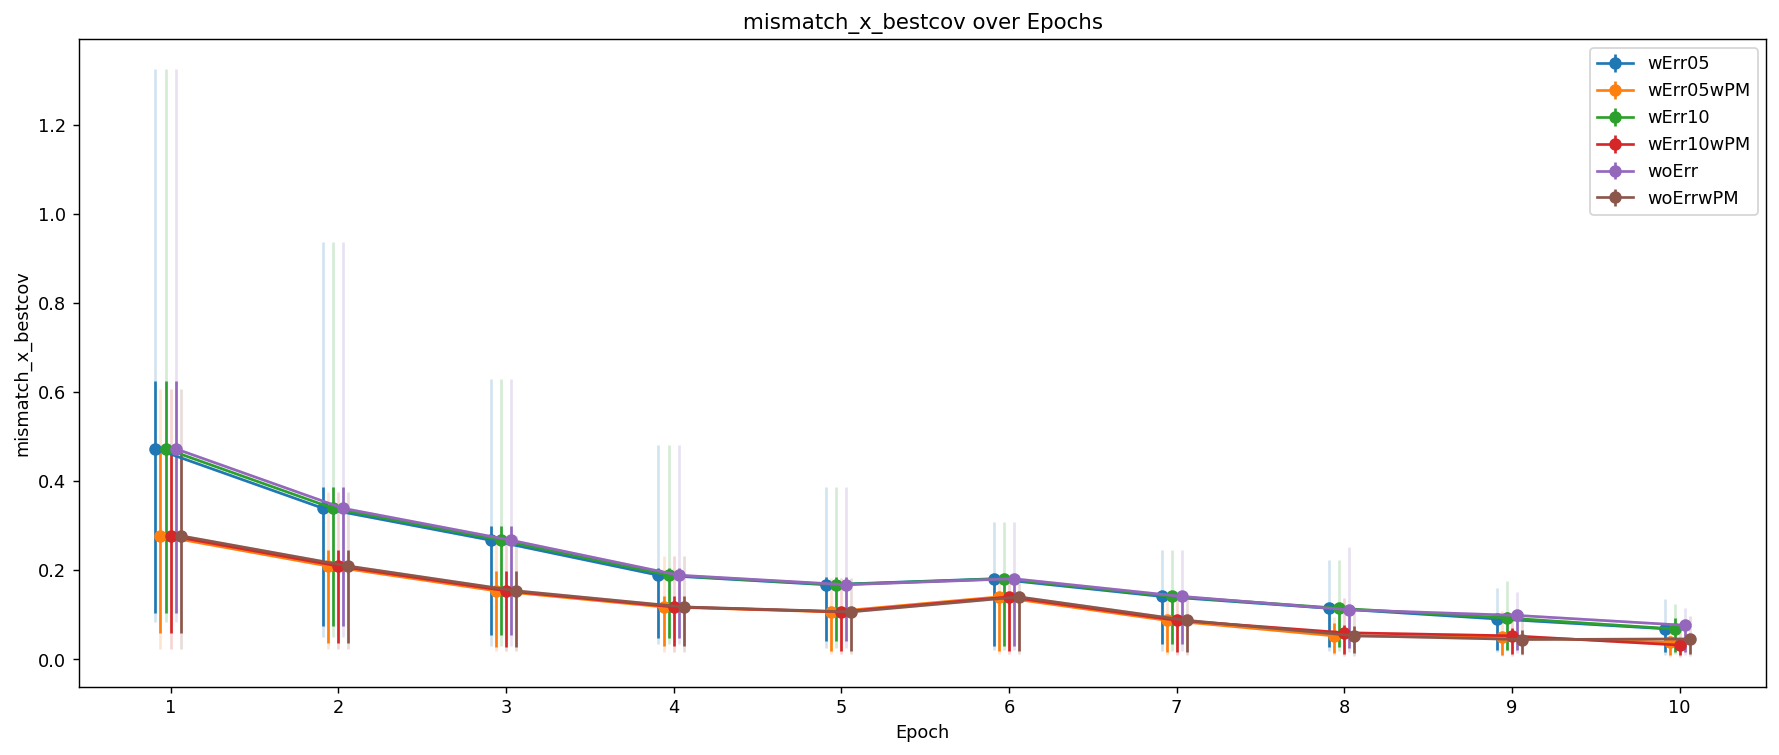

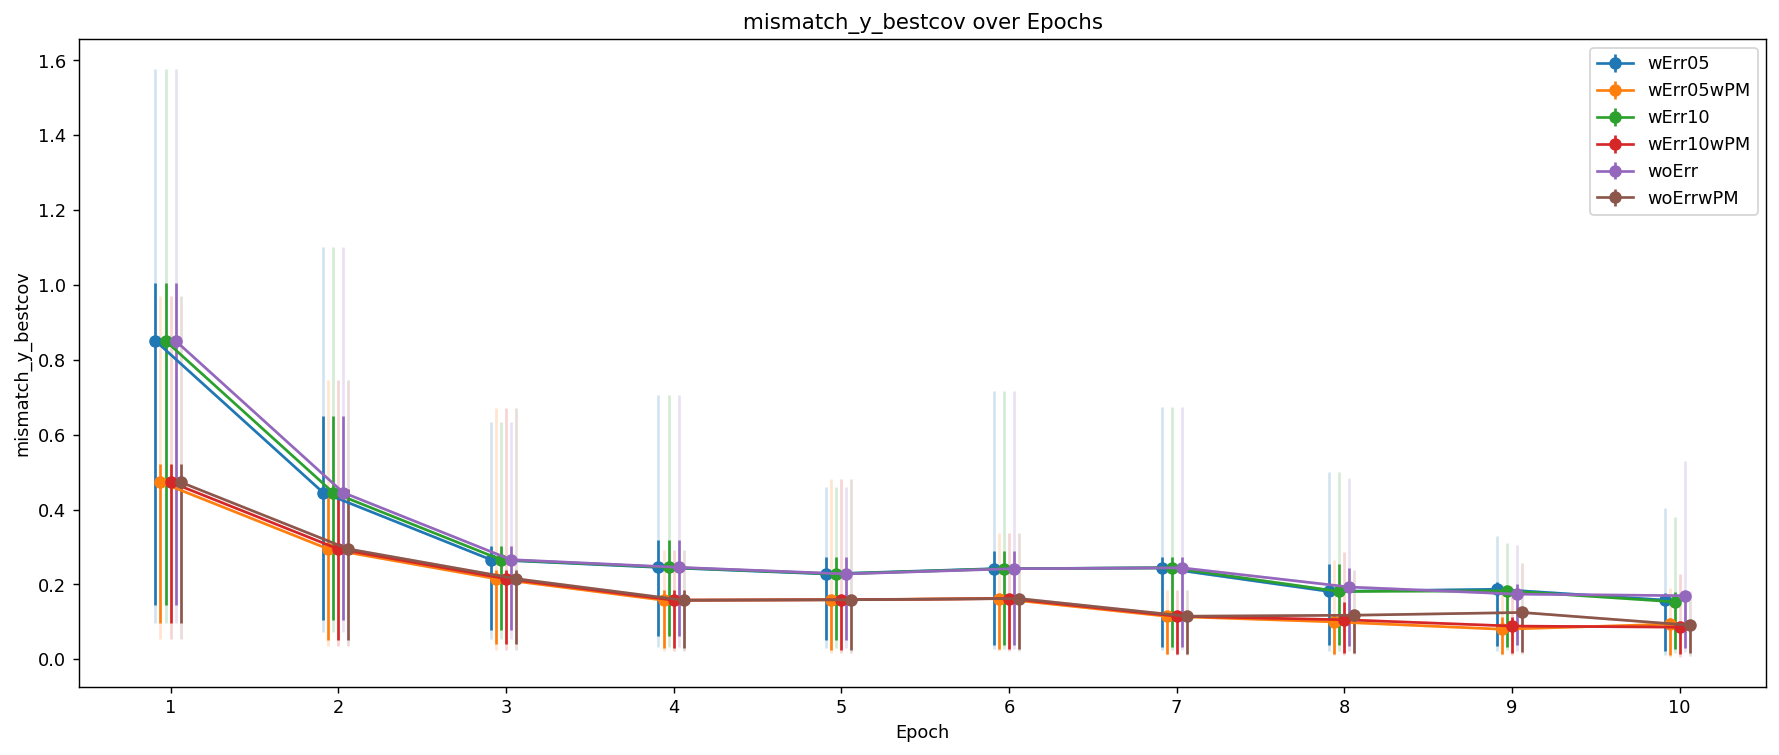

In [19]:
# Example: list of specific conditions to plot
# ['n_init', 'isEmitPrior', 'sample_model_err', 
#  'virtual_beamQmodelerr', 'bootstrap', 'fit_err', 'isPMscan']
selected_conditions = [
    (8, False, True,  0.5, False, False, False),
    (8, False, True,  0.5, False, False, True),
    (8, False, True,  1.0, False, False, False),
    (8, False, True,  1.0, False, False, True),
    (8, False, False, 0.5, False, False, False),
    (8, False, False, 0.5, False, False, True)
]
# Plot the conditions
plot_conditions(benchmark, selected_conditions,labels=['wErr05','wErr05wPM',
                                                       'wErr10','wErr10wPM',
                                                       'woErr','woErrwPM'])

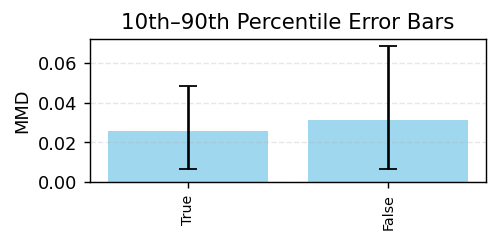

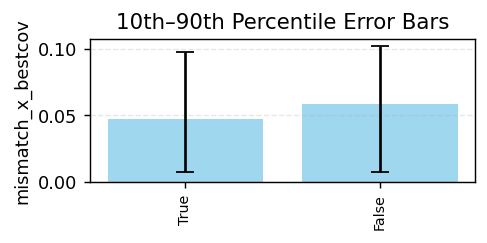

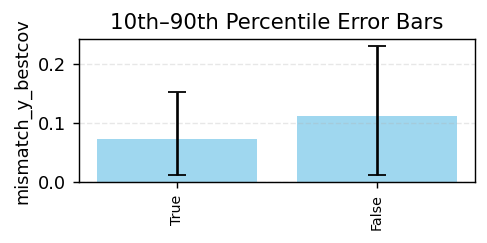

In [20]:
for label in ['MMD_best','mismatch_x_bestcov','mismatch_y_bestcov']:
    plot_bar(label, benchmark=benchmark, condition_cols = ['isEmitPrior'], fig_size=(4,2), plot_sorted_only=True)

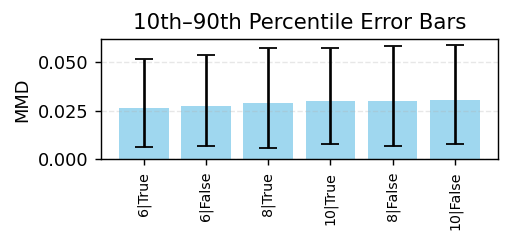

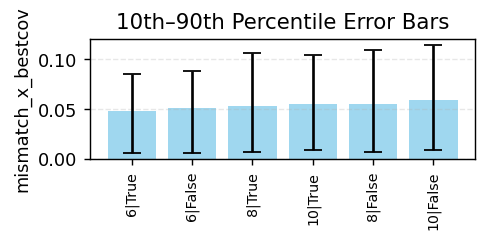

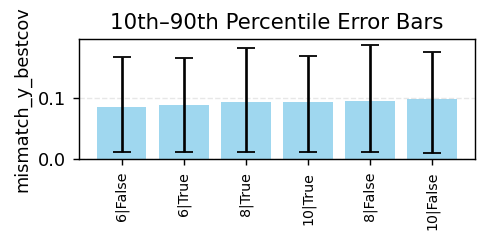

In [21]:
for label in ['MMD_best','mismatch_x_bestcov','mismatch_y_bestcov']:
    plot_bar(label, benchmark=benchmark, condition_cols = ['n_init','sample_model_err'], fig_size=(4,2), plot_sorted_only=True)

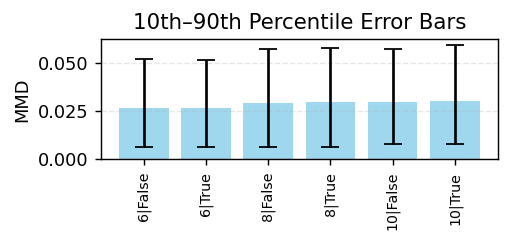

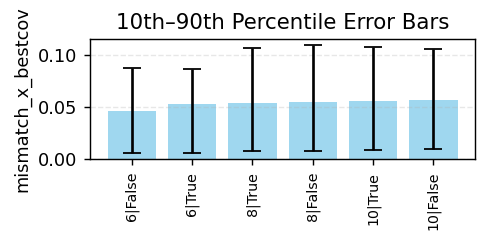

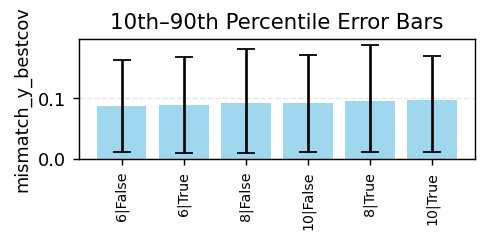

In [22]:
for label in ['MMD_best','mismatch_x_bestcov','mismatch_y_bestcov']:
    plot_bar(label, benchmark=benchmark, condition_cols = ['n_init','bootstrap'], fig_size=(4,2), plot_sorted_only=True)

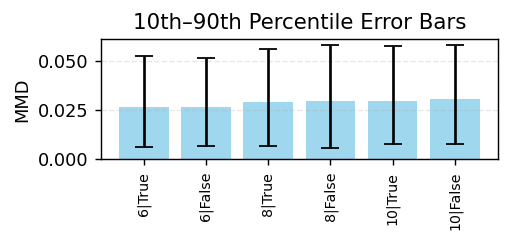

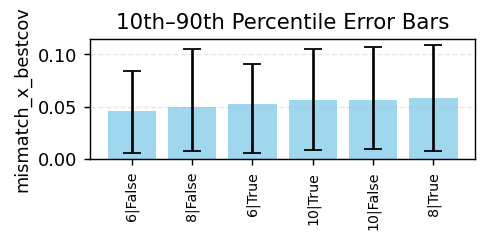

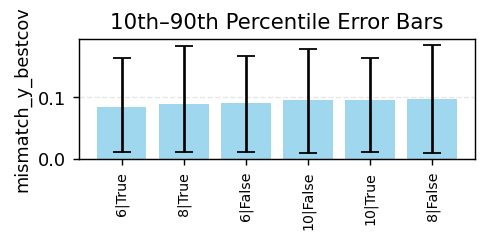

In [23]:
for label in ['MMD_best','mismatch_x_bestcov','mismatch_y_bestcov']:
    plot_bar(label, benchmark=benchmark, condition_cols = ['n_init','fit_err'], fig_size=(4,2), plot_sorted_only=True)

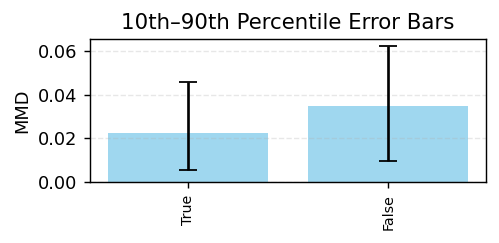

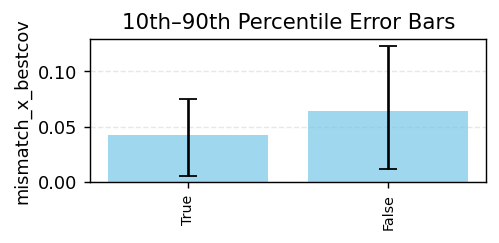

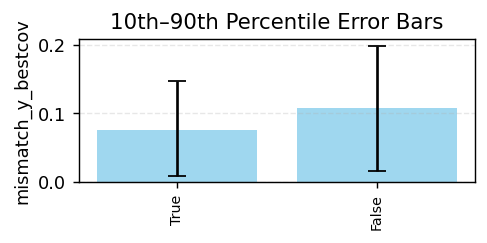

In [24]:
for label in ['MMD_best','mismatch_x_bestcov','mismatch_y_bestcov']:
    plot_bar(label, benchmark=benchmark, condition_cols = ['isPMscan'], fig_size=(4,2), plot_sorted_only=True)